# Maya4 Sample World Map

This lightweight map demo samples a few products from the public bucket and queries Copernicus footprint metadata with `phidown`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from maya4 import DEFAULT_BUCKET_ID, extract_location_from_zarr_filename_with_phidown, list_base_files_in_bucket, parse_product_filename

sample_products = []
seen_modes = set()
for file_name in sorted(list_base_files_in_bucket(DEFAULT_BUCKET_ID, relative_path=True)):
    if not file_name.endswith('.zarr'):
        continue
    meta = parse_product_filename(file_name)
    if meta['stripmap_mode'] in seen_modes:
        continue
    seen_modes.add(meta['stripmap_mode'])
    sample_products.append(file_name)
    if len(sample_products) == 3:
        break

rows = []
for file_name in sample_products:
    info = extract_location_from_zarr_filename_with_phidown(file_name)
    rows.append(
        {
            'filename': file_name,
            'stripmap_mode': info.get('swath_mode'),
            'polarization': info.get('polarization'),
            'latitude': info.get('latitude'),
            'longitude': info.get('longitude'),
            'success': info.get('success'),
        }
    )

locations = pd.DataFrame(rows)
print(locations.to_string(index=False))



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/miniconda3/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/miniconda3/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/miniconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/miniconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/miniconda3/lib/python3.1

AttributeError: _ARRAY_API not found


Found 1 products in the time range:

Searching for matching products...

Top 10 products in the time range:
                                                                       Name                                                                                                                                GeoFootprint                                                                     ContentDate                                                                                                                 S3Path
0  S1C_S1_RAW__0SDV_20250328T052810_20250328T052835_001637_002A0D_2E88.SAFE  {'type': 'Polygon', 'coordinates': [[[21.4468, 68.4099], [20.3377, 66.9842], [22.0868, 66.7944], [23.2965, 68.2091], [21.4468, 68.4099]]]}  {'Start': '2025-03-28T05:28:10.699000Z', 'End': '2025-03-28T05:28:35.086000Z'}  /eodata/Sentinel-1/SAR/S1_RAW__0S/2025/03/28/S1C_S1_RAW__0SDV_20250328T052810_20250328T052835_001637_002A0D_2E88.SAFE



Found 1 products in the time range:

Searching for matching products...

Top 10 products in the time range:
                                                                       Name                                                                                                                                     GeoFootprint                                                                     ContentDate                                                                                                                 S3Path
0  S1C_S2_RAW__0SDV_20250331T205042_20250331T205107_001690_002D5C_A096.SAFE  {'type': 'Polygon', 'coordinates': [[[139.4495, 35.6944], [139.1019, 34.2191], [139.9475, 34.1196], [140.3105, 35.5939], [139.4495, 35.6944]]]}  {'Start': '2025-03-31T20:50:42.822000Z', 'End': '2025-03-31T20:51:07.268000Z'}  /eodata/Sentinel-1/SAR/S2_RAW__0S/2025/03/31/S1C_S2_RAW__0SDV_20250331T205042_20250331T205107_001690_002D5C_A096.SAFE



Found 1 products in the time range:

Searching for matching products...

Top 10 products in the time range:
                                                                       Name                                                                                                                                    GeoFootprint                                                                     ContentDate                                                                                                                 S3Path
0  S1C_S3_RAW__0SDV_20250414T083258_20250414T083323_001887_0039F0_6F57.SAFE  {'type': 'Polygon', 'coordinates': [[[140.6298, 35.0128], [140.296, 36.4838], [139.4266, 36.3892], [139.7764, 34.9189], [140.6298, 35.0128]]]}  {'Start': '2025-04-14T08:32:58.742000Z', 'End': '2025-04-14T08:33:23.114000Z'}  /eodata/Sentinel-1/SAR/S3_RAW__0S/2025/04/14/S1C_S3_RAW__0SDV_20250414T083258_20250414T083323_001887_0039F0_6F57.SAFE
                                                     

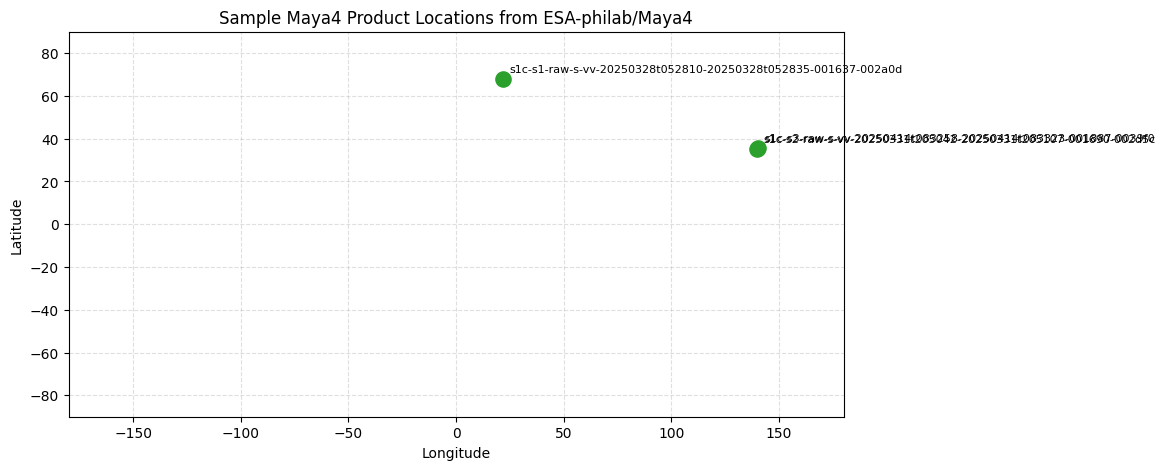

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt

valid_locations = locations.dropna(subset=['latitude', 'longitude']).copy()

if valid_locations.empty:
    raise RuntimeError('No geolocated products were returned by phidown for the sampled products.')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(valid_locations['longitude'], valid_locations['latitude'], s=120, color='#2ca02c')
for _, row in valid_locations.iterrows():
    ax.annotate(row['filename'].split('.zarr')[0], (row['longitude'], row['latitude']), fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_title('Sample Maya4 Product Locations from ESA-philab/Maya4')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()
